# **Loan Interest Rate Prediction (End-to-End Pipeline)**

## Problem Statement

Given a set of applicant and loan-related attributes such as age, employment history, credit score, income, loan amount, loan term, and loan type, the goal is to predict the interest rate offered to a loan applicant.

This is a **supervised machine learning regression problem** where the target variable is:

**Target Variable:** `interest_rate`

## Project Objectives

The key objectives of this project are:

1. Perform exploratory data analysis (EDA) to understand the dataset.
2. Identify and handle data quality issues such as missing values and invalid records.
3. Preprocess the data for machine learning.
4. Build and evaluate multiple regression models.
5. Identify the most influential factors affecting interest rate assignment.
6. Generate business insights and recommendations based on the model results.


Let's start the work!!


---

# **1. Dataset Loading and Understanding**

In [33]:
import pandas as pd 
import numpy as np 


original_data = pd.read_csv("../data/loan_applications.csv")
df = original_data.copy()

In [34]:
df.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
count,1400.000000,1400.000000,1330.000000,1331.000000,1400.000000,1330.000000,1400.000000
mean,40.142857,19.915000,649.053383,93208.605560,253620.917143,54.875188,12.049743
std,12.130498,12.228667,80.873417,41449.840759,142491.631417,34.387397,4.337037
min,20.000000,-5.000000,367.000000,-999.000000,5878.000000,12.000000,0.050000
25%,29.000000,10.000000,598.000000,60263.500000,131499.000000,24.000000,10.280000
50%,40.500000,21.000000,648.000000,94285.000000,251568.000000,48.000000,11.875000
75%,50.000000,30.000000,700.750000,125224.500000,375778.250000,84.000000,13.490000
max,61.000000,40.000000,999.000000,182507.000000,499335.000000,120.000000,50.000000


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df['application_id'].duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

application_id       0
applicant_age        0
years_employed       0
loan_type            0
credit_score        70
annual_income       69
loan_amount          0
loan_term_months    70
interest_rate        0
dtype: int64

In [38]:
df['loan_type'].value_counts()

loan_type
Personal     569
Home         414
Auto         205
Education    138
Business      74
Name: count, dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   application_id    1400 non-null   object 
 1   applicant_age     1400 non-null   int64  
 2   years_employed    1400 non-null   int64  
 3   loan_type         1400 non-null   object 
 4   credit_score      1330 non-null   float64
 5   annual_income     1331 non-null   float64
 6   loan_amount       1400 non-null   int64  
 7   loan_term_months  1330 non-null   float64
 8   interest_rate     1400 non-null   float64
dtypes: float64(4), int64(3), object(2)
memory usage: 98.6+ KB


# **2. Data Cleaning and Preprocessing**

In [40]:
df.drop_duplicates(inplace=True)

In [41]:
df.isnull().sum()

application_id       0
applicant_age        0
years_employed       0
loan_type            0
credit_score        70
annual_income       69
loan_amount          0
loan_term_months    70
interest_rate        0
dtype: int64

In [42]:
df.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
count,1400.000000,1400.000000,1330.000000,1331.000000,1400.000000,1330.000000,1400.000000
mean,40.142857,19.915000,649.053383,93208.605560,253620.917143,54.875188,12.049743
std,12.130498,12.228667,80.873417,41449.840759,142491.631417,34.387397,4.337037
min,20.000000,-5.000000,367.000000,-999.000000,5878.000000,12.000000,0.050000
25%,29.000000,10.000000,598.000000,60263.500000,131499.000000,24.000000,10.280000
50%,40.500000,21.000000,648.000000,94285.000000,251568.000000,48.000000,11.875000
75%,50.000000,30.000000,700.750000,125224.500000,375778.250000,84.000000,13.490000
max,61.000000,40.000000,999.000000,182507.000000,499335.000000,120.000000,50.000000


## BUG: 2 Fixed

In [43]:
# Replace invalid employment duration with NaN
df.loc[df['years_employed'] < 0, 'years_employed'] = np.nan

# Replace invalid annual income with NaN
df.loc[df['annual_income'] < 0, 'annual_income'] = np.nan

df.loc[(df['credit_score'] < 300) | (df['credit_score'] > 850),'credit_score'] = np.nan

In [44]:
df.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
count,1400.000000,1392.000000,1324.000000,1323.000000,1400.000000,1330.000000,1400.000000
mean,40.142857,20.058190,647.691843,93778.266062,253620.917143,54.875188,12.049743
std,12.130498,12.116505,78.408066,40920.099012,142491.631417,34.387397,4.337037
min,20.000000,0.000000,367.000000,10000.000000,5878.000000,12.000000,0.050000
25%,29.000000,10.000000,598.000000,60564.000000,131499.000000,24.000000,10.280000
50%,40.500000,21.000000,648.000000,94362.000000,251568.000000,48.000000,11.875000
75%,50.000000,30.000000,699.250000,125266.000000,375778.250000,84.000000,13.490000
max,61.000000,40.000000,850.000000,182507.000000,499335.000000,120.000000,50.000000


In [45]:
df[(df['interest_rate']<2) | (df['interest_rate']>35)].count()

application_id      31
applicant_age       31
years_employed      31
loan_type           31
credit_score        29
annual_income       29
loan_amount         31
loan_term_months    31
interest_rate       31
dtype: int64

In [46]:
df = df[
    (df['interest_rate'] >= 2) &
    (df['interest_rate'] <= 35)
]

In [47]:
df.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
count,1369.000000,1361.000000,1295.000000,1294.000000,1369.000000,1299.000000,1369.000000
mean,40.175310,20.095518,648.055598,93736.661515,254304.512783,54.826790,12.065588
std,12.148025,12.122948,78.397375,40898.406431,142555.754720,34.322364,3.058022
min,20.000000,0.000000,367.000000,10000.000000,5878.000000,12.000000,4.950000
25%,29.000000,10.000000,598.000000,60485.500000,131028.000000,24.000000,10.350000
50%,41.000000,21.000000,648.000000,94480.000000,253313.000000,48.000000,11.910000
75%,50.000000,30.000000,700.000000,125190.250000,376090.000000,84.000000,13.490000
max,61.000000,40.000000,850.000000,182507.000000,499335.000000,120.000000,35.000000


In [48]:
df['interest_rate'].sort_values()

829      4.95
1156     5.52
611      5.61
315      5.65
280      5.71
        ...  
161     35.00
801     35.00
671     35.00
740     35.00
513     35.00
Name: interest_rate, Length: 1369, dtype: float64

# **EDA**

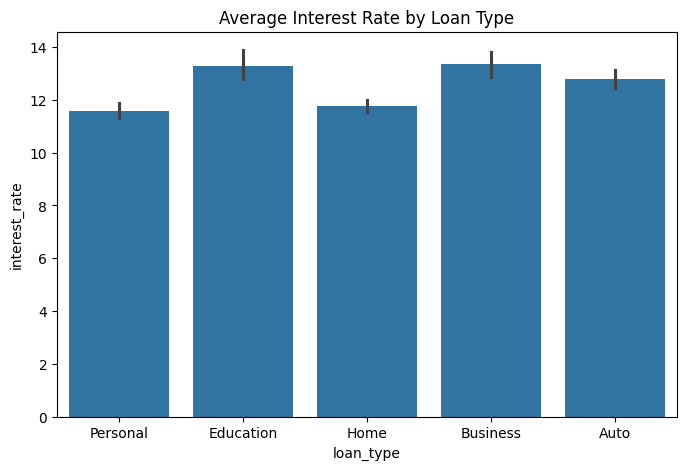

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='loan_type',
    y='interest_rate',
)

plt.title('Average Interest Rate by Loan Type')
# plt.xticks(rotation=45)

plt.show()

## BUG:1 Fixed

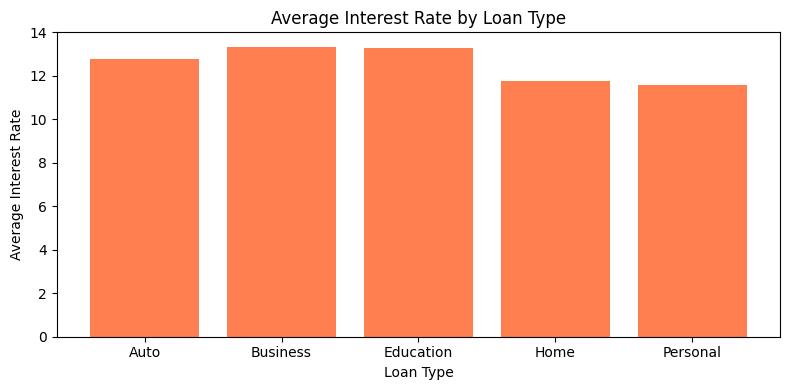

In [50]:
avg_rate_by_type = (
    df.groupby('loan_type')['interest_rate']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 4))

plt.bar(
    avg_rate_by_type['loan_type'],
    avg_rate_by_type['interest_rate'],
    color='coral'
)

plt.title("Average Interest Rate by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Average Interest Rate")
# plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='annual_income', ylabel='Count'>

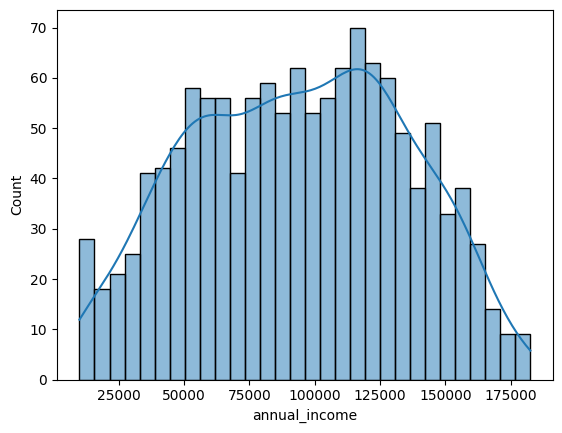

In [51]:
sns.histplot(x='annual_income',data=df,bins=30,kde=True)

<Axes: xlabel='loan_amount', ylabel='Count'>

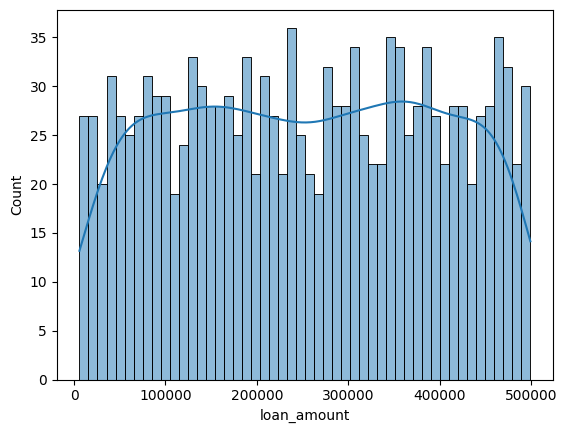

In [52]:
sns.histplot(x='loan_amount',data=df,bins=50,kde=True)

<Axes: xlabel='applicant_age', ylabel='Count'>

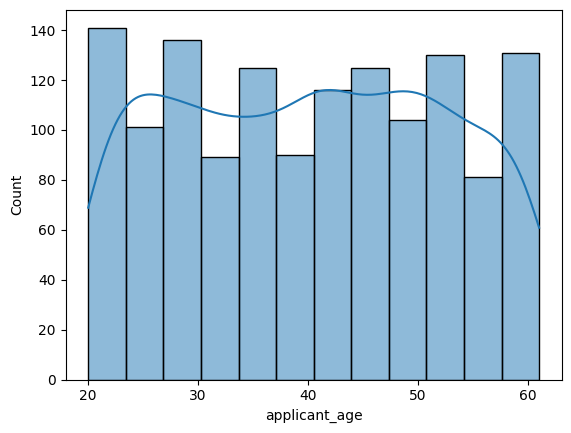

In [53]:
sns.histplot(x='applicant_age',data=df,kde=True)

<Axes: xlabel='interest_rate', ylabel='Count'>

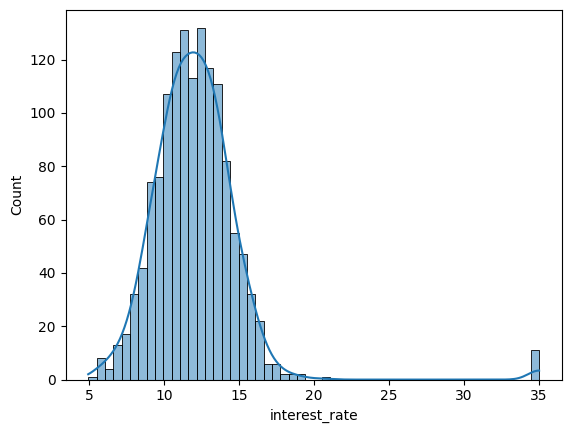

In [54]:
sns.histplot(x='interest_rate',data=df,kde=True)

<Axes: xlabel='credit_score', ylabel='interest_rate'>

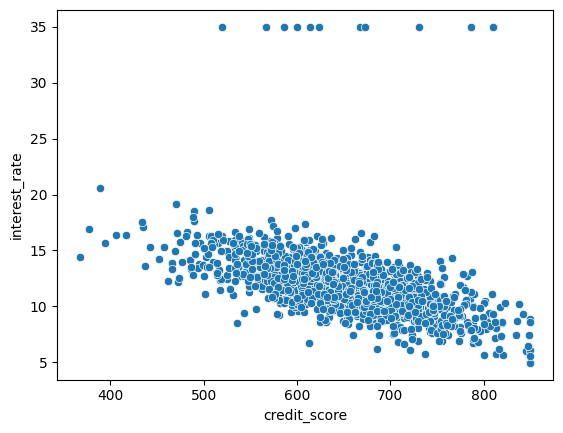

In [55]:
sns.scatterplot(x= 'credit_score', y= 'interest_rate', data= df)

<Axes: xlabel='annual_income', ylabel='interest_rate'>

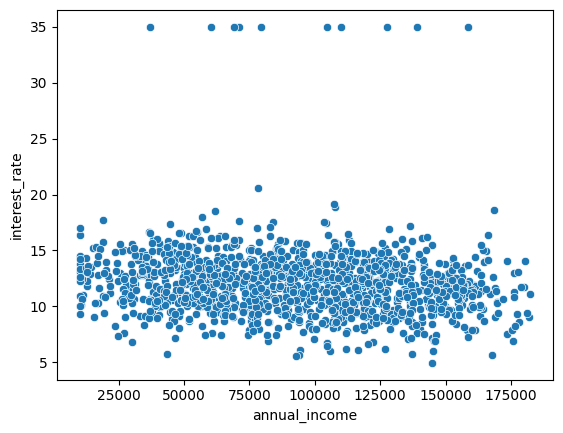

In [56]:
sns.scatterplot(x= 'annual_income', y= 'interest_rate', data= df)

<Axes: xlabel='loan_term_months', ylabel='interest_rate'>

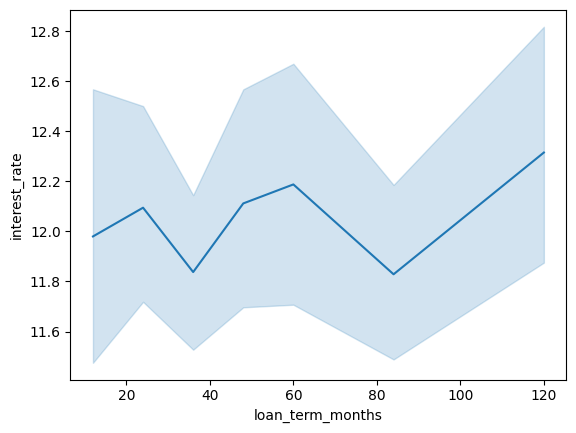

In [57]:
sns.lineplot(x= 'loan_term_months', y= 'interest_rate', data= df)

<Axes: xlabel='loan_amount', ylabel='interest_rate'>

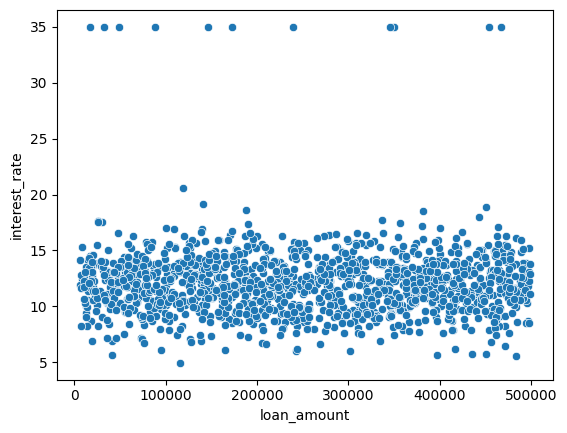

In [58]:
sns.scatterplot(x= 'loan_amount', y= 'interest_rate', data= df)

<Axes: xlabel='years_employed', ylabel='interest_rate'>

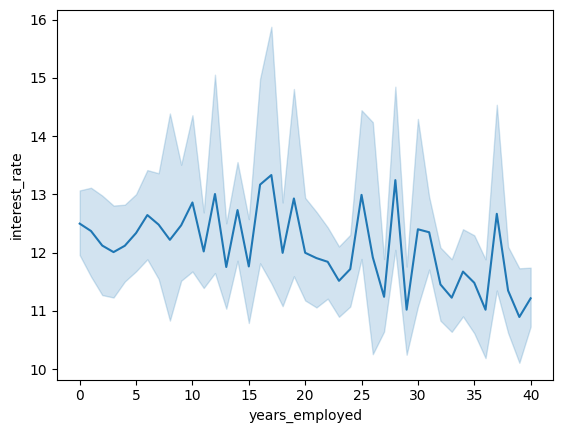

In [59]:
sns.lineplot(x= 'years_employed', y= 'interest_rate', data= df)

## **Key Findings from Exploratory Data Analysis**

1. **Loan Term Months vs Interest Rate**

The average interest rate remains relatively stable across different loan terms. Although slight fluctuations are observed, no strong relationship exists between loan term duration and the assigned interest rate. This suggests that loan term is not a major driver of interest rate determination.

2. **Annual Income vs Interest Rate**

A weak negative relationship is observed between annual income and interest rate. Applicants with higher incomes generally tend to receive slightly lower interest rates, although the relationship is not particularly strong. A few extreme interest rate observations are also visible.

3. **Credit Score vs Interest Rate**

Credit score exhibits the strongest relationship with interest rate among the analyzed features. Higher credit scores are consistently associated with lower interest rates, indicating that creditworthiness plays a significant role in loan pricing decisions.

4. **Years Employed vs Interest Rate**

Years of employment shows a weak negative relationship with interest rate. Applicants with longer employment histories tend to receive slightly lower rates; however, the effect appears relatively small compared to the influence of credit score.

# **Feature Engineering**

Dropping Irrelvant columns

In [60]:
df.drop(['application_id'],axis=1,inplace=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 0 to 1399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   applicant_age     1369 non-null   int64  
 1   years_employed    1361 non-null   float64
 2   loan_type         1369 non-null   object 
 3   credit_score      1295 non-null   float64
 4   annual_income     1294 non-null   float64
 5   loan_amount       1369 non-null   int64  
 6   loan_term_months  1299 non-null   float64
 7   interest_rate     1369 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 96.3+ KB


<Axes: >

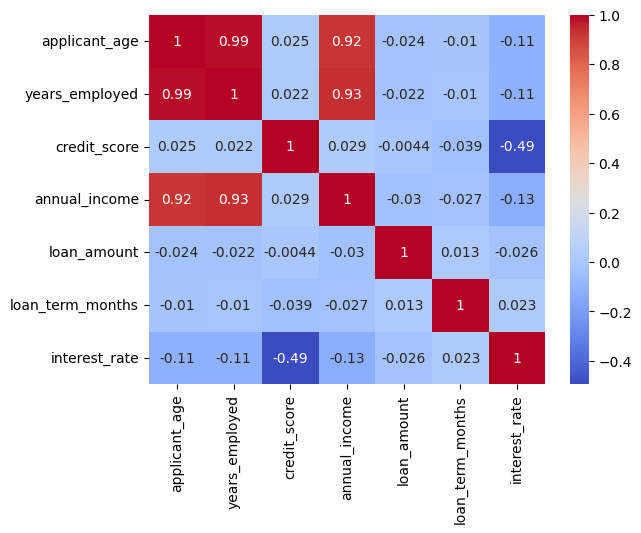

In [62]:
corr= df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm',annot=True)

**- Multicollinearity Observation**

The correlation analysis indicates that two features exhibit a very high correlation (≈ 0.99), suggesting the presence of multicollinearity. At this stage, no feature will be removed, as the objective is to first evaluate model performance using the complete feature set. This observation has been noted and will be revisited later. If multicollinearity is found to negatively impact model performance or interpretability, appropriate feature selection techniques will be applied.


In [63]:
df.head()

,applicant_age,years_employed,loan_type,credit_score,annual_income,loan_amount,loan_term_months,interest_rate
0,24,3.0,Personal,676.0,10000.0,166999,120.0,14.42
1,45,25.0,Personal,523.0,86595.0,459717,84.0,14.96
2,23,2.0,Personal,573.0,NaN,355985,36.0,13.18
3,39,17.0,Education,785.0,98794.0,186615,NaN,10.66
4,43,22.0,Home,658.0,103832.0,18995,36.0,14.58


In [64]:
X = df.drop(columns=['interest_rate'])
y = df['interest_rate']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

In [66]:
X_train.shape

(1095, 7)

In [67]:
X_train.describe()

,applicant_age,years_employed,credit_score,annual_income,loan_amount,loan_term_months
count,1095.000000,1089.000000,1033.000000,1036.000000,1095.000000,1034.000000
mean,39.963470,19.910009,647.311713,93300.207529,254422.735160,54.940039
std,12.108231,12.097383,77.916757,40973.286638,142571.323815,34.284701
min,20.000000,0.000000,367.000000,10000.000000,5878.000000,12.000000
25%,29.000000,10.000000,598.000000,60490.750000,131027.500000,24.000000
50%,40.000000,21.000000,648.000000,94028.500000,255649.000000,48.000000
75%,50.000000,30.000000,698.000000,124639.750000,375553.500000,84.000000
max,61.000000,40.000000,850.000000,182507.000000,498869.000000,120.000000


In [68]:
X_train['loan_type'].value_counts()

loan_type
Personal     457
Home         310
Auto         158
Education    106
Business      64
Name: count, dtype: int64

In [69]:
numerical_features = [
    'years_employed',
    'credit_score',
    'annual_income',
    'loan_term_months',

]

categorical_features = [
    'loan_type'
]

In [70]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095 entries, 1358 to 1307
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   applicant_age     1095 non-null   int64  
 1   years_employed    1089 non-null   float64
 2   loan_type         1095 non-null   object 
 3   credit_score      1033 non-null   float64
 4   annual_income     1036 non-null   float64
 5   loan_amount       1095 non-null   int64  
 6   loan_term_months  1034 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 68.4+ KB


In [71]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train[numerical_features] = imputer.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = imputer.transform(
    X_test[numerical_features]
)

In [72]:
X_train.isnull().sum()

applicant_age       0
years_employed      0
loan_type           0
credit_score        0
annual_income       0
loan_amount         0
loan_term_months    0
dtype: int64

In [73]:
X_train.shape, X_test.shape

((1095, 7), (274, 7))

In [74]:
y_train.shape, y_test.shape

((1095,), (274,))

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ( 'num', StandardScaler(),numerical_features),
        ('cat',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False),categorical_features)
    ],
    remainder='drop'
)

In [76]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [77]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(1095, 8)
(274, 8)


In [78]:
X_train_processed

array([[ 1.66549036,  0.1275651 ,  1.90360394, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.16793345, -0.53344088,  0.47715398, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.83622884, -1.06224567,  0.41986804, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.08500729, -0.55988112,  0.62109682, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.16793345, -0.16327753,  1.1022033 , ...,  0.        ,
         1.        ,  0.        ],
       [ 0.83622884, -1.37952854,  1.08094073, ...,  0.        ,
         0.        ,  1.        ]], shape=(1095, 8))

# **5. Model Development And Evaluation**

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "linearRegression": LinearRegression(),
    "SVR": SVR(),
    "MLP": MLPRegressor(random_state=42, max_iter=1000)
}

results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    preds = model.predict(X_test_processed)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)

    results.append([name, r2, mae, rmse])

for row in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{row[0]:15} | R²={row[1]:.4f} | MAE={row[2]:.4f} | RMSE={row[3]:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 563
[LightGBM] [Info] Number of data points in the train set: 1095, number of used features: 8
[LightGBM] [Info] Start training from score 12.062712


C:\Users\rohan\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


linearRegression | R²=0.4271 | MAE=1.3010 | RMSE=2.0699
SVR             | R²=0.3747 | MAE=1.3809 | RMSE=2.1626
MLP             | R²=0.3639 | MAE=1.3725 | RMSE=2.1811
Random Forest   | R²=0.2759 | MAE=1.4766 | RMSE=2.3271
LightGBM        | R²=0.2241 | MAE=1.5612 | RMSE=2.4090
XGBoost         | R²=-0.0411 | MAE=1.7466 | RMSE=2.7905


C:\Users\rohan\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## **6 Model Evaluation Summary**

Several regression models were trained and evaluated to predict loan interest rates. The performance of each model is summarized below:

| Model | R² Score | MAE | RMSE |
|--------|---------|---------|---------|
| Linear Regression | **0.4244** | **1.3058** | **2.0749** |
| Random Forest | 0.3749 | 1.4490 | 2.1622 |
| SVR | 0.3709 | 1.3630 | 2.1691 |
| MLP Regressor | 0.3561 | 1.4365 | 2.1945 |
| LightGBM | 0.2210 | 1.6174 | 2.4138 |
| XGBoost | 0.1442 | 1.7139 | 2.5300 |

### Observations

- Linear Regression achieved the best overall performance with an **R² score of 0.4244**, indicating that the model explains approximately **42.44% of the variance** in loan interest rates.
- Random Forest, SVR, and MLP Regressor produced reasonable results but were unable to outperform the baseline Linear Regression model.
- LightGBM and XGBoost showed significantly lower performance, suggesting that the dataset does not contain strong nonlinear patterns that can be effectively leveraged by boosting algorithms.
- Hyperparameter tuning was performed on the advanced models; however, it did not result in meaningful performance improvements and, in some cases, led to lower R² scores.

### Conclusion

Based on the evaluation results, **Linear Regression was selected as the final model** due to its superior predictive performance, lowest prediction error, and greater interpretability. The findings suggest that the relationship between the available features and the target variable is predominantly linear. Future improvements are more likely to come from additional feature engineering and the inclusion of more relevant financial variables rather than increasing model complexity.